In [ ]:
!pip install joblib
!pip install scikit-learn 
!pip install matplotlib
!pip install seaborn

In [138]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
%matplotlib inline

# Reading the Data from the File


In [139]:
lines_to_read = 1000
max_rows = 3000000
skip_rows = 200

final_rows = []
# Reads only 1000 lines at a time
lines_read = pd.read_csv("itineraries.csv", chunksize=lines_to_read)

curr_idx = 0
for chunk in lines_read:
    if curr_idx >= max_rows:
        break
    
    # Chooses every 200th entry in the dataset
    selected_indices = []
    for i in range(len(chunk)):
        if (curr_idx + i) % skip_rows == 0:
            selected_indices.append(i)

    chunk = chunk.iloc[selected_indices]
    final_rows.append(chunk)
    curr_idx += lines_to_read

# Combines the selected rows into a dataframe 
df = pd.concat(final_rows, ignore_index=True)
# Shuffles the rows randomly and resets indices of rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


# Encoding and Engineering Features


In [140]:
# Encoding booleans as 1/0 integers 
df['isBasicEconomy'] = df['isBasicEconomy'].astype(int)
df['isRefundable'] = df['isRefundable'].astype(int)
df['isNonStop'] = df['isNonStop'].astype(int)

# Converting to datetime object
df['searchDate'] = pd.to_datetime(df['searchDate'])
df['flightDate'] = pd.to_datetime(df['flightDate'])

# Engineering new feature - 'daysUntilFlight' 
df['daysUntilFlight'] = (df['flightDate'] - df['searchDate']).dt.days

# Engineering two new features
# Getting day of the week using ordinal encoding
df['searchDayOfWeek'] = df['searchDate'].dt.dayofweek + 1
df['flightDayOfWeek'] = df['flightDate'].dt.dayofweek + 1

# One-hot encoding airport names
encoded_airports = pd.get_dummies(df[['startingAirport', 'destinationAirport']], prefix=['from', 'to'])
df = pd.concat([df, encoded_airports], axis=1)

# Engineering 'airline_dummies'
# Working with 'segmentsAirlineName'
def get_main_airline(name):
    if pd.isna(name):
        return 0
    else:
        if "||" in name:
            return name.split("||")[0]
        else:
            return name
        
df['mainAirline'] = df['segmentsAirlineName'].apply(get_main_airline)
airline_dummies = pd.get_dummies(df['mainAirline'])
df = pd.concat([df, airline_dummies], axis=1)

# Transforming 'travelDuration'
def convert_time(duration):
    result = duration
    result = result[2:]
    hour = ""
    minute = ""
    while result[0].isdigit():
        hour += result[0]
        result = result[1:]
    result = result[1:]
    if result:
        while result and result[0].isdigit():
            minute += result[0]
            result = result[1:]

    hour = int(hour) if hour else 0
    minute = int(minute) if minute else 0      
    return hour * 60 + minute
df['travelDuration'] = df['travelDuration'].apply(convert_time)

# Transforming 'segmentsDurationInSeconds'
def seconds_to_total(total_seconds):
    if ("||" in total_seconds):
        seconds = total_seconds.split("||")
        total_seconds = 0
        for second in seconds:
            total_seconds += int(second)
        return total_seconds
    else:
        return int(total_seconds)
df['segmentsDurationInSeconds'] = df['segmentsDurationInSeconds'].apply(seconds_to_total)

# Transforming 'segmentsDistance'
def miles_to_total(total_miles):
    # Segments distance (some rows are missing data)
    if pd.isna(total_miles):
        return 0
    if ("||" in str(total_miles)):
        miles = total_miles.split("||")
        total_miles = 0
        for mile in miles:
            if mile and mile.isdigit():
                total_miles += int(mile)
        return int(total_miles)
    else:
        return int(total_miles) if str(total_miles).isdigit() else 0
df['segmentsDistance'] = df['segmentsDistance'].apply(miles_to_total)



# Dropping Features and Encoding Target Value

In [141]:
# Dropping rows that don't have values for these two features
df = df.dropna(subset=['totalTravelDistance', 'segmentsDistance'])

# Creating target value using existing 'baseFare' feature
NATIONAL_AVERAGE_TICKET_PRICE = 397.64
df['isAboveAvg'] = (df['baseFare'] > NATIONAL_AVERAGE_TICKET_PRICE).astype(int)


# Dropping all the features that won't be used
df = df.drop(['legId', 'fareBasisCode', 'totalFare', 'searchDate', 
              'flightDate', 'segmentsDepartureTimeEpochSeconds', 
              'segmentsDepartureTimeRaw', 'segmentsArrivalTimeEpochSeconds', 
              'segmentsArrivalTimeRaw', 'segmentsArrivalAirportCode', 
              'segmentsDepartureAirportCode', 'segmentsAirlineCode', 
              'segmentsEquipmentDescription', 'segmentsCabinCode', 
              'startingAirport', 'destinationAirport', 'segmentsAirlineName', 
              'mainAirline', 'baseFare'], axis=1)


# Splitting the Data

In [142]:
# Splitting data into training, validation, and test sets
train_data, temp_data = train_test_split(df, test_size=0.30, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Creating target columns
target_train = train_data['isAboveAvg']
target_val = val_data['isAboveAvg']
target_test = test_data['isAboveAvg']

train_data = train_data.drop(['isAboveAvg'], axis=1)
val_data = val_data.drop(['isAboveAvg'], axis=1)
test_data = test_data.drop(['isAboveAvg'], axis=1)

print("Training Data Size:", len(train_data), "entries\nValidation Data Size:", len(val_data), "entries\nTesting Data Size:", len(test_data),"entries")

Training Data Size: 9869 entries
Validation Data Size: 2115 entries
Testing Data Size: 2115 entries


In [18]:
# Cheching features' data types 
# print(train_data.dtypes)
# df.isnull().sum()

# Plotting Individual Features (Histograms) 

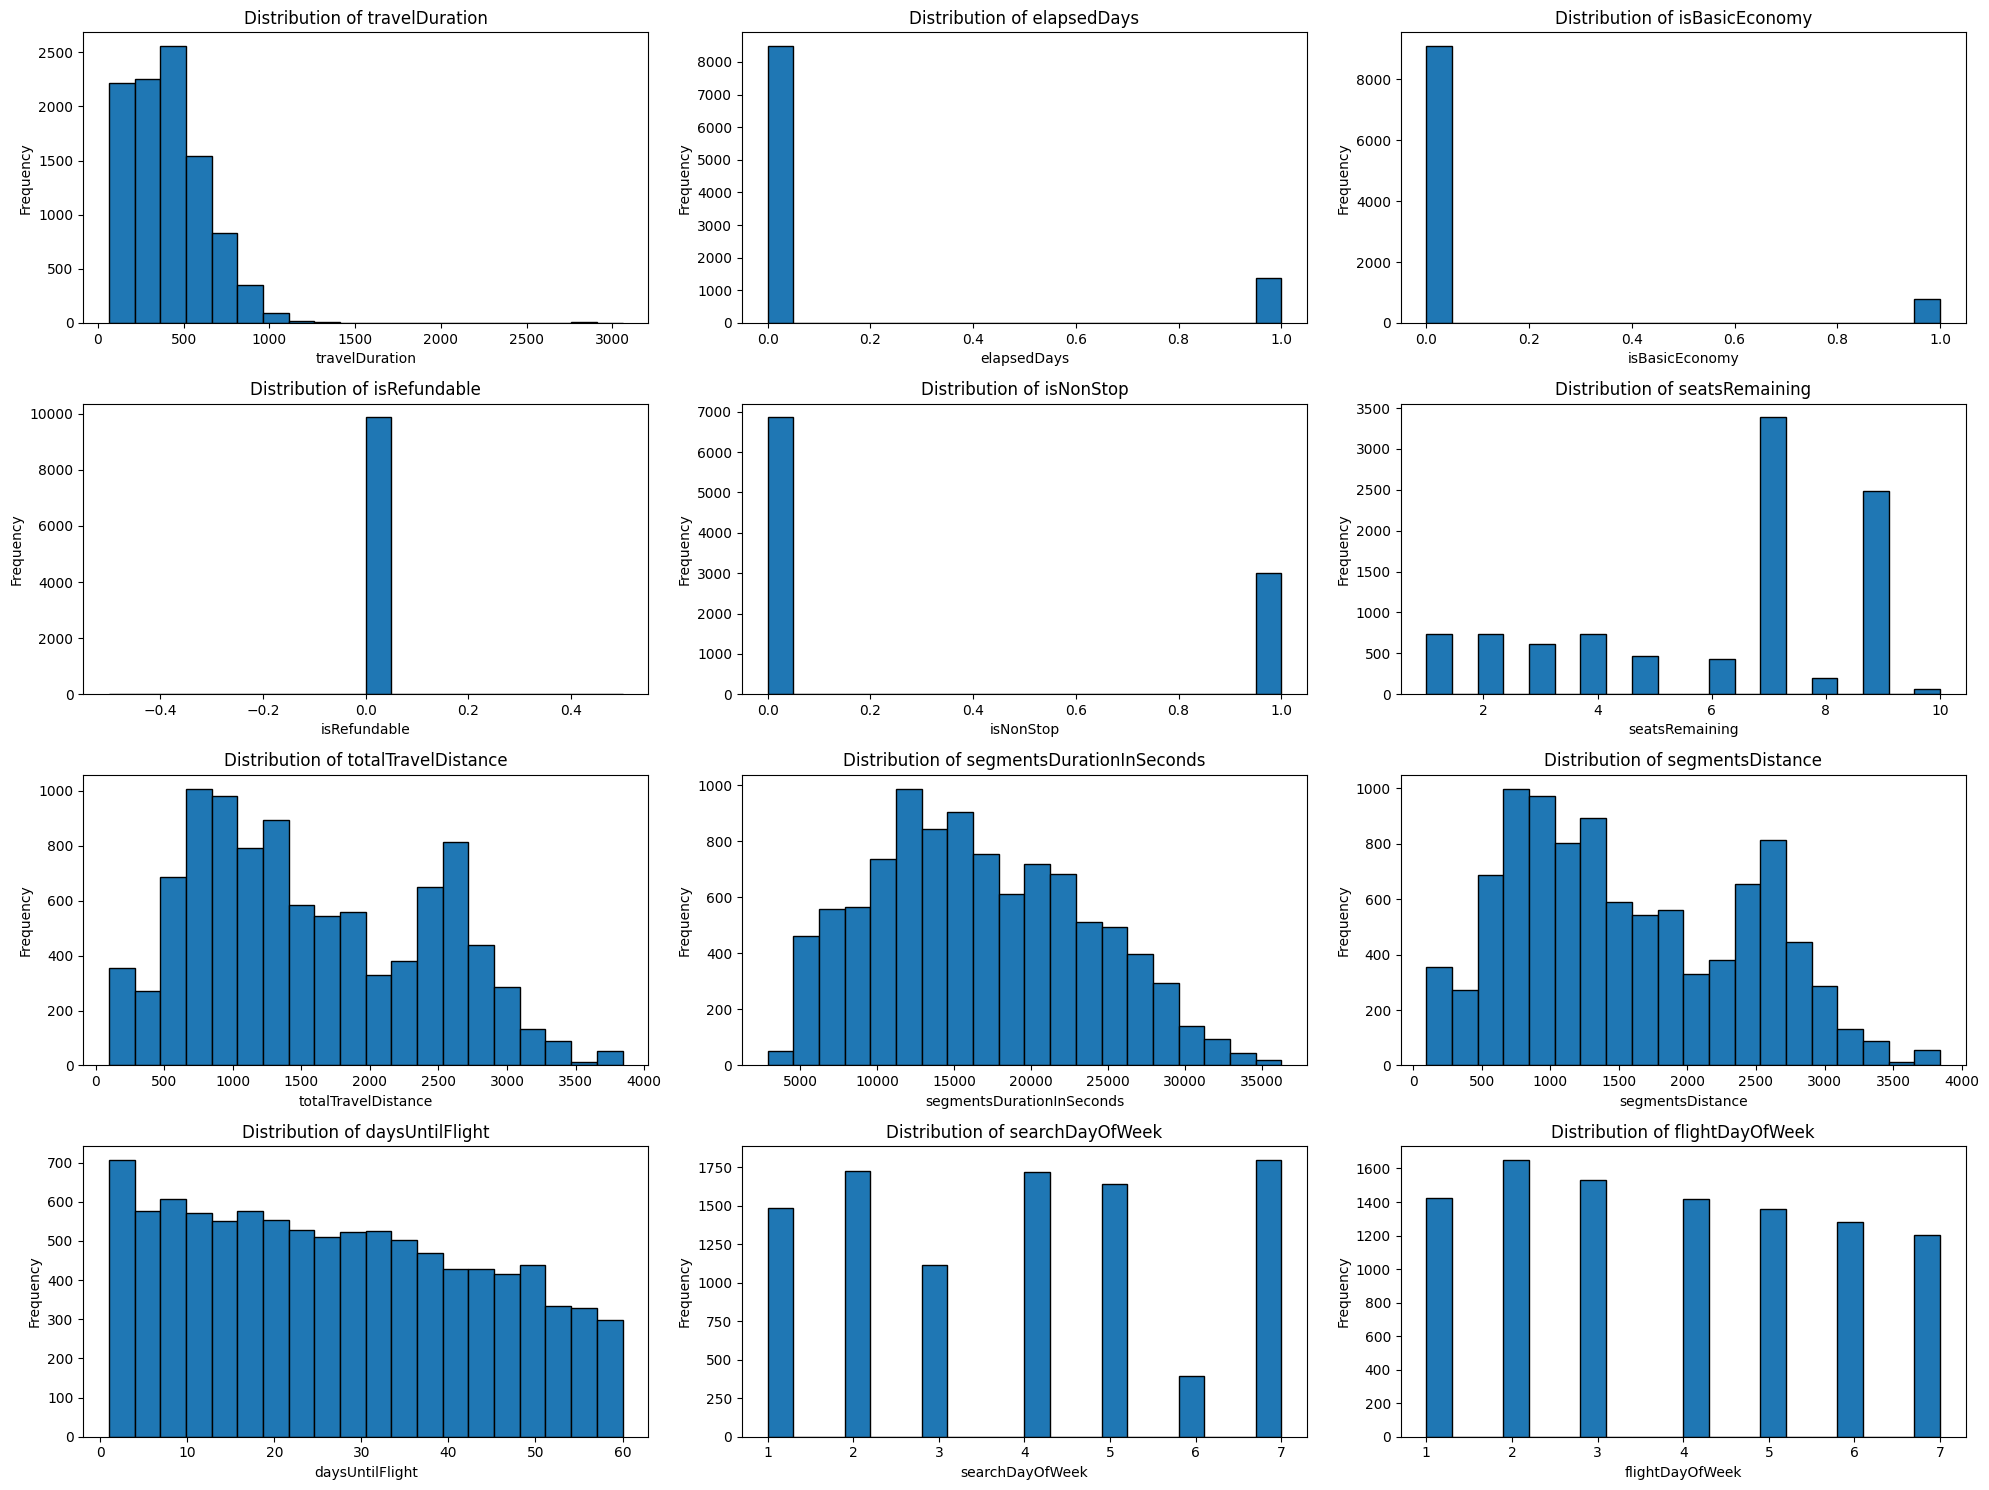

In [147]:
all_features = ['travelDuration', 'elapsedDays', 'isBasicEconomy', 'isRefundable', 'isNonStop', 'seatsRemaining', 'totalTravelDistance', 
                    'segmentsDurationInSeconds', 'segmentsDistance', 'daysUntilFlight', 'searchDayOfWeek', 'flightDayOfWeek']

plt.figure(figsize = (20, 15))

for i in range(1,len(all_features) + 1):
    plt.subplot(4, 3, i) 
    plt.hist(train_data[all_features[i - 1]], bins = 20, edgecolor = 'black')
    plt.title(f'Distribution of {all_features[i - 1]}')
    plt.xlabel(all_features[i - 1])
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# Plotting Features VS Target Variable

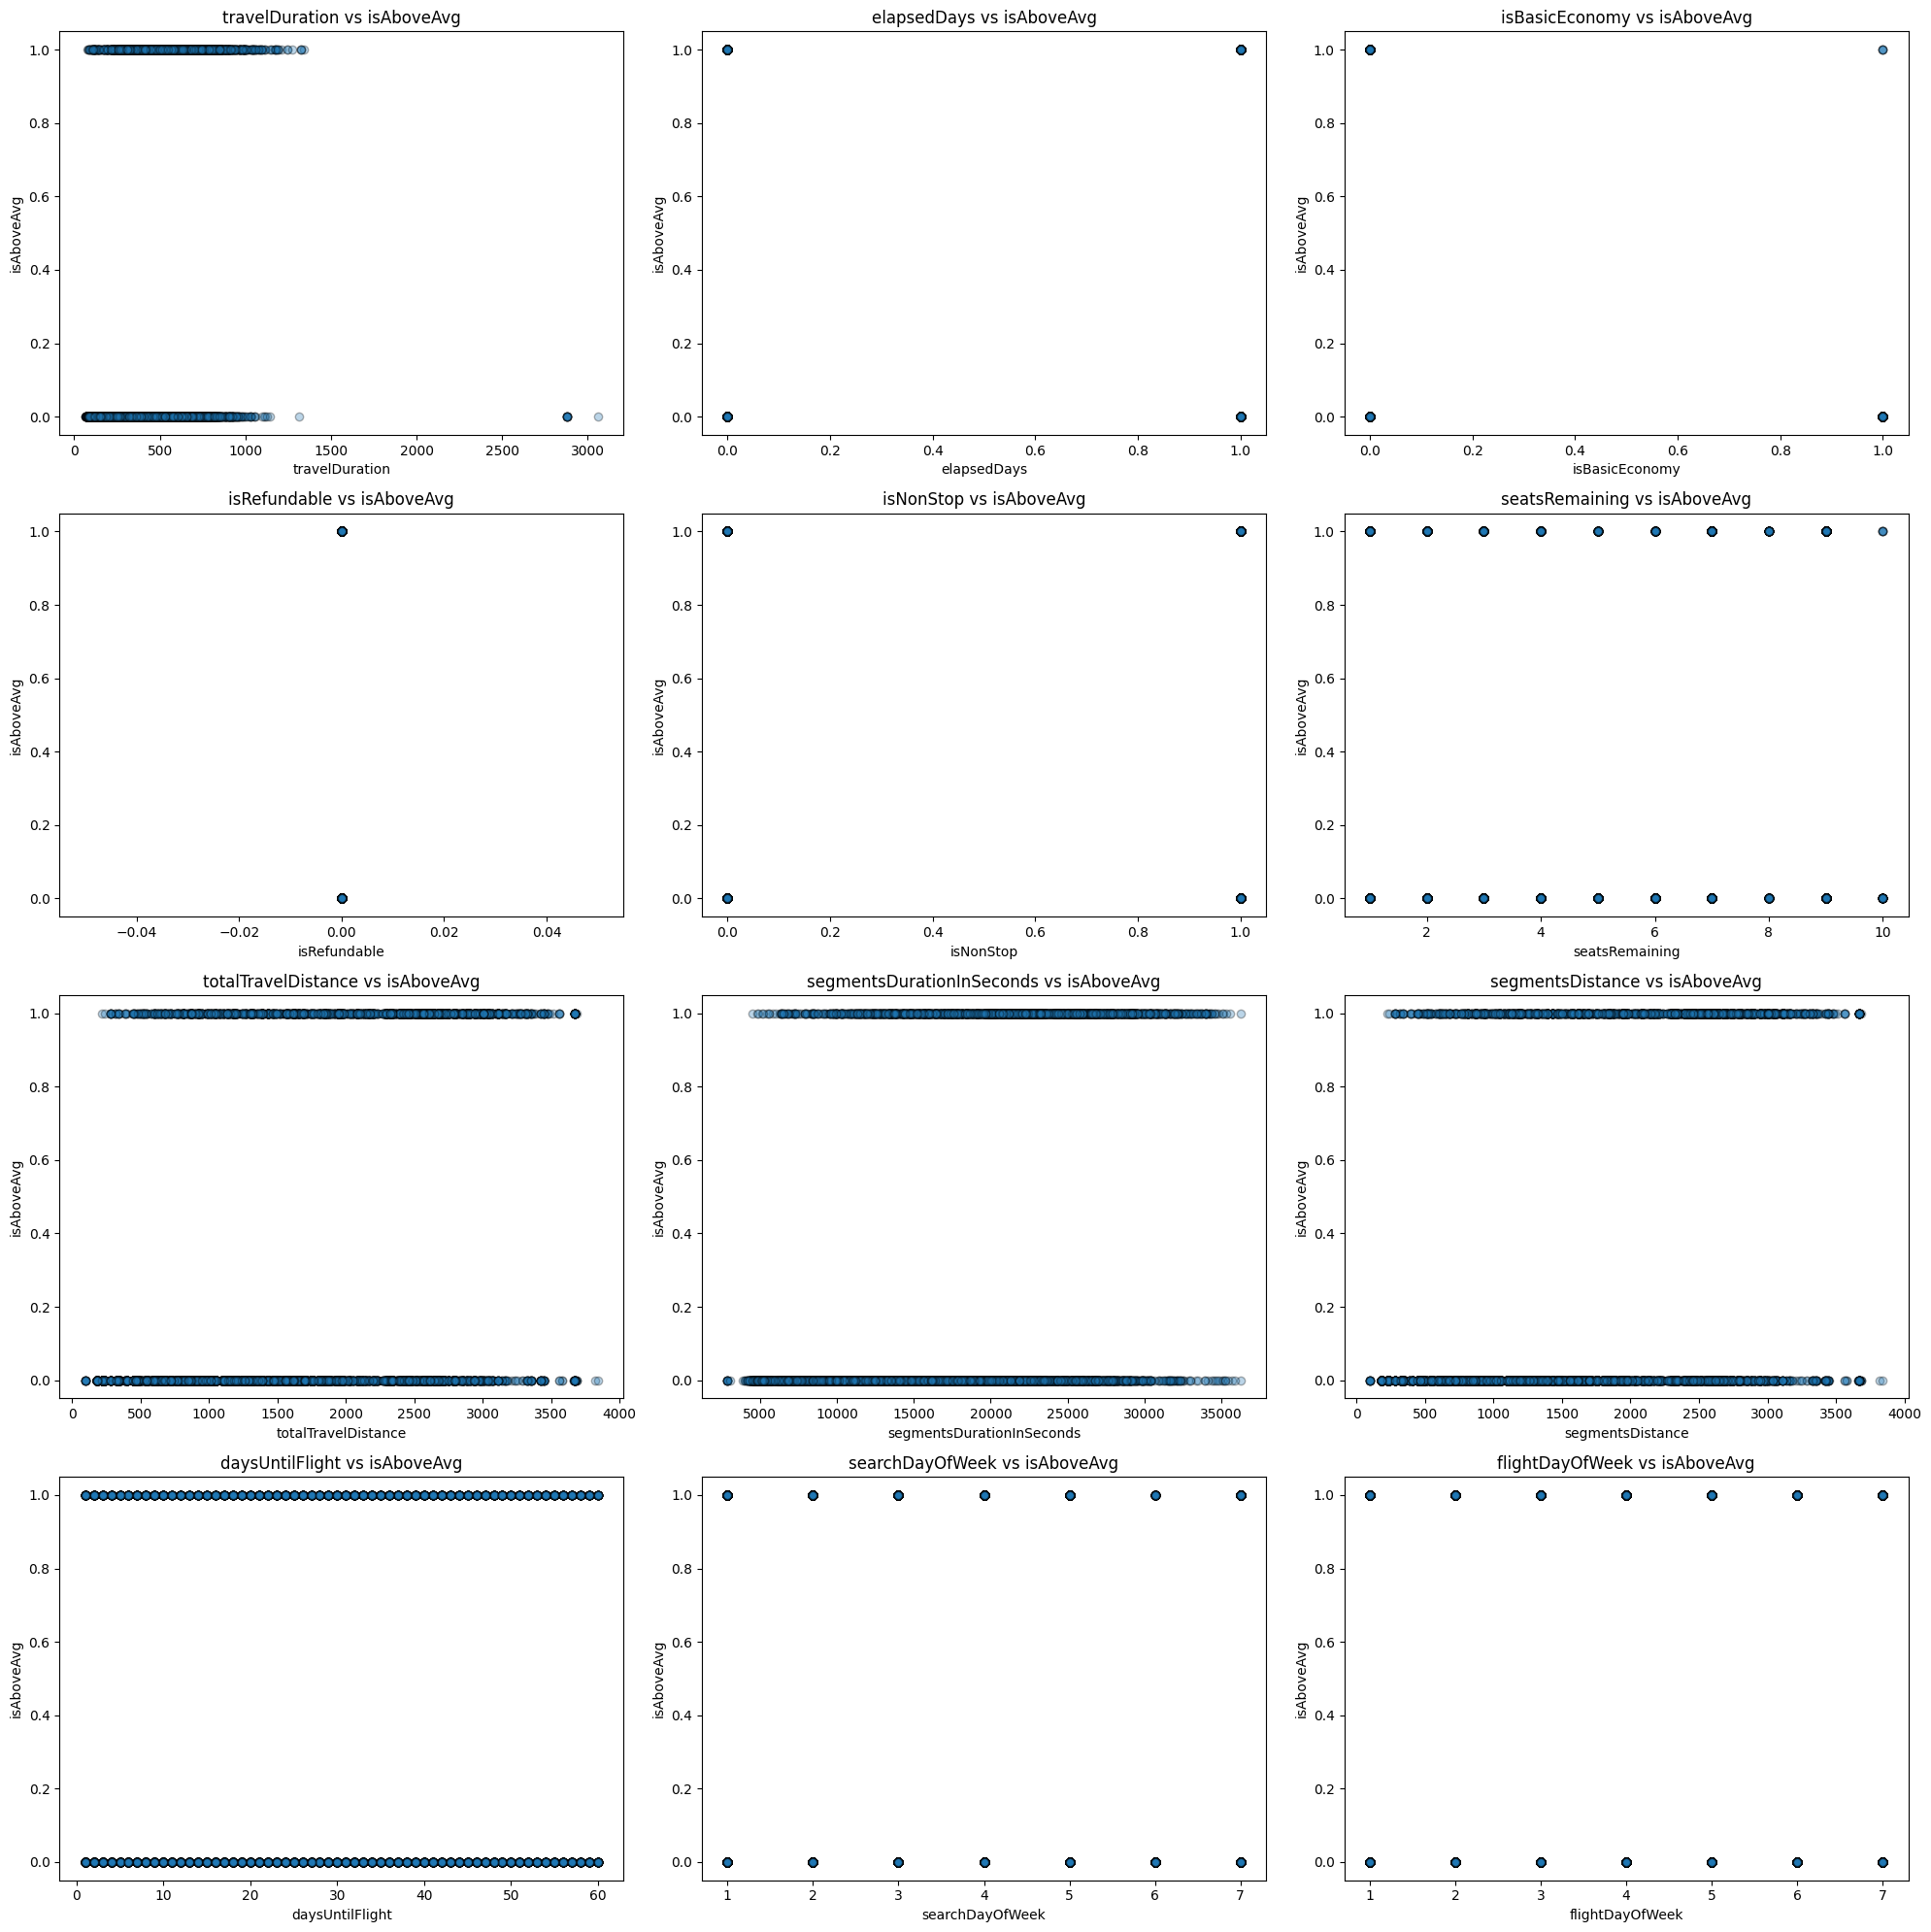

In [51]:
plt.figure(figsize=(20, 20))

for i in range(1, len(all_features) + 1):
    plt.subplot(4, 3, i)
    plt.scatter(train_data[all_features[i-1]], target_train, alpha=0.3, edgecolor='k')
    plt.title(f'{all_features[i-1]} vs isAboveAvg')
    plt.xlabel(all_features[i-1])
    plt.ylabel('isAboveAvg')

plt.tight_layout()
plt.show()


# Scaling Data

In [71]:
scaler_object = StandardScaler()  

train_scaled = scaler_object.fit_transform(train_data)
val_scaled = scaler_object.fit_transform(val_data)
test_scaled = scaler_object.transform(test_data)

# K-Means Clustering

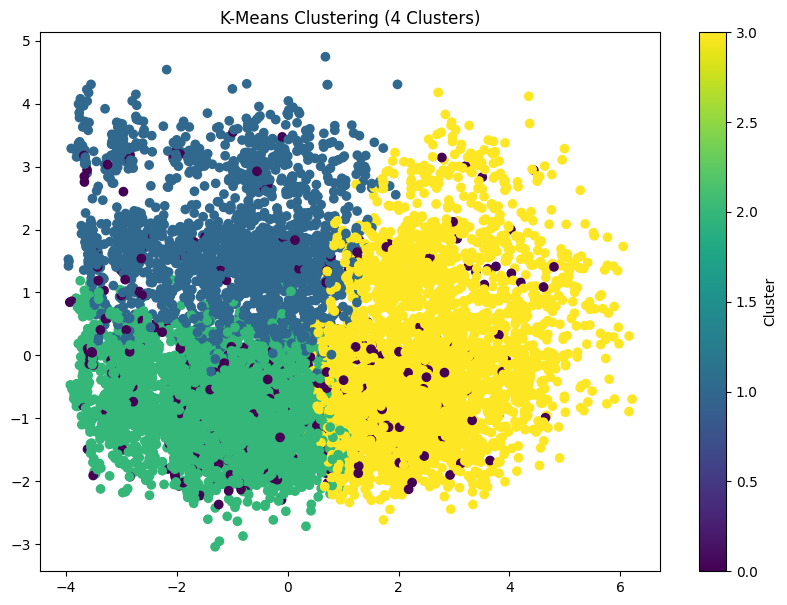

In [108]:
kmeans = KMeans(n_clusters = 4, random_state = 42)
kmeans.fit(train_scaled)
clusters = kmeans.labels_
pca = PCA(n_components = 5)
 
plot_pca = pca.fit_transform(train_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(plot_pca[:, 0], plot_pca[:, 1], c = clusters, cmap = 'viridis')
plt.title('K-Means Clustering (4 Clusters)')
plt.colorbar(label = 'Cluster')
plt.show()


# Correlation Matrix

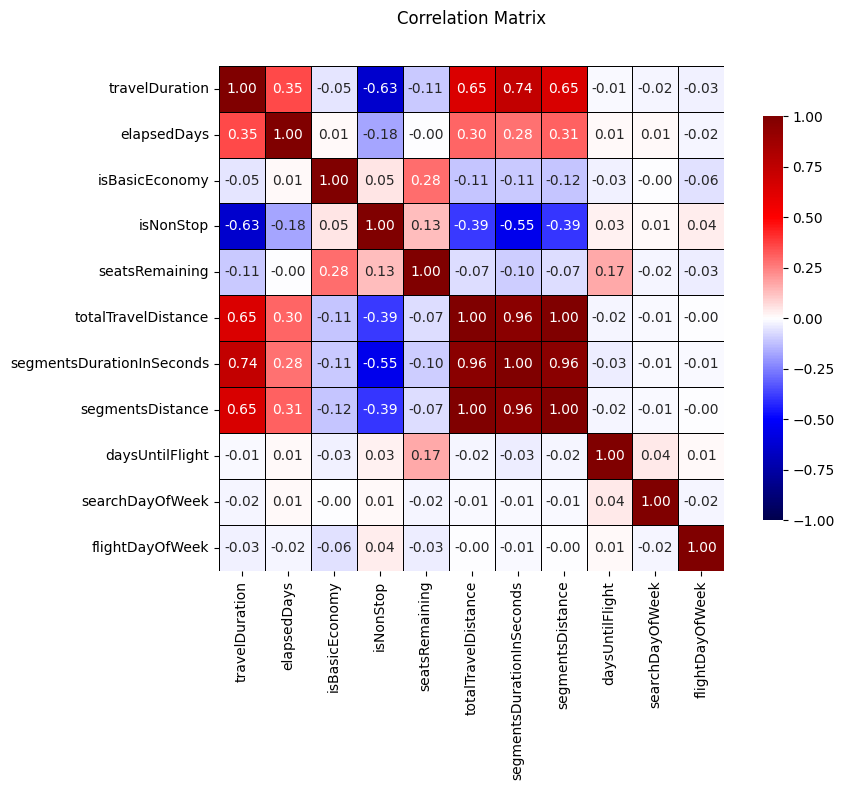

In [178]:
selected_features = ['travelDuration', 'elapsedDays', 'isBasicEconomy',  'isNonStop','seatsRemaining', 
                     'totalTravelDistance', 'segmentsDurationInSeconds','segmentsDistance', 
                     'daysUntilFlight', 'searchDayOfWeek', 'flightDayOfWeek']

correlation_matrix = train_data[selected_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='seismic', 
            vmin=-1, vmax=1, 
            square=True, 
            linewidths=0.5, 
            fmt=".2f", 
            linecolor='black',
            cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix", pad=30)
plt.tight_layout()
plt.show()



# Logistic Regression
### Untransformed Data

In [148]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")
for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(train_scaled, target_train)

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None)
    recall = recall_score(target_val, val_predicted, average=None)
    f1 = f1_score(target_val, val_predicted, average=None)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")





C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.75347    0.747991   0.745192   0.914286   0.998068   0.05694    0.853289   0.107203  
0.001    0.810112   0.802364   0.820803   0.708092   0.934965   0.435943   0.874172   0.539648  
0.01     0.820347   0.817021   0.84375    0.708831   0.921442   0.52847    0.880886   0.605505  
0.1      0.823386   0.81513    0.846246   0.695652   0.914359   0.540925   0.878985   0.608609  
1        0.823589   0.814657   0.845742   0.694954   0.914359   0.539146   0.878713   0.607214  
10       0.823285   0.815603   0.847164   0.695455   0.913715   0.544484   0.879182   0.610778  
100      0.823285   0.815603   0.847164   0.695455   0.913715   0.544484   0.879182   0.610778  
1000     0.823386   0.815603   0.847164   0.695455   0.913715   0.544484   0.879182   0.610778  


### Degree 2 Transformation

In [149]:
degree_2 = PolynomialFeatures(degree=2, include_bias=False)

train_2 = degree_2.fit_transform(train_scaled)
val_2 = degree_2.transform(val_scaled)
test_2 = degree_2.transform(test_scaled)

c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")
for c in c_values:
    model = LogisticRegression(C=c, max_iter=2000)
    model.fit(train_2, target_train)

    val_predicted = model.predict(val_2)
    train_predicted = model.predict(train_2)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None)
    recall = recall_score(target_val, val_predicted, average=None)
    f1 = f1_score(target_val, val_predicted, average=None)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")




C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.823792   0.807092   0.814043   0.763699   0.95557    0.396797   0.879147   0.522248  
0.001    0.863715   0.846809   0.867304   0.769231   0.934321   0.604982   0.899566   0.677291  
0.01     0.876685   0.846809   0.876301   0.746888   0.921442   0.640569   0.898305   0.689655  
0.1      0.8855     0.840189   0.873387   0.729508   0.915003   0.633452   0.893711   0.678095  
1        0.884993   0.838298   0.873075   0.723577   0.912428   0.633452   0.892317   0.675522  
10       0.886311   0.834043   0.872367   0.710579   0.906632   0.633452   0.88917    0.669802  
100      0.886108   0.83026    0.872195   0.69863    0.900837   0.635231   0.886284   0.665424  
1000     0.887425   0.830733   0.873204   0.698444   0.900193   0.63879    0.886493   0.667286  


### Degree 3 Transformation

In [150]:
degree_3 = PolynomialFeatures(degree=3)

train_3 = degree_3.fit_transform(train_scaled)
val_3 = degree_3.transform(val_scaled)
test_3 = degree_3.transform(test_scaled)

c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(train_3, target_train)

    train_predicted = model.predict(train_3)
    val_predicted = model.predict(val_3)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None)
    recall = recall_score(target_val, val_predicted, average=None)
    f1 = f1_score(target_val, val_predicted, average=None)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


    

C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.885601   0.84539    0.868389   0.760532   0.930457   0.61032    0.898353   0.677196  
0.001    0.93586    0.842553   0.880299   0.72407    0.909208   0.658363   0.89452    0.689655  
0.01     0.975884   0.82695    0.873036   0.687023   0.894398   0.640569   0.883588   0.662983  
0.1      0.994731   0.814184   0.872272   0.651706   0.87508    0.645907   0.873674   0.648794  
1        0.999493   0.800946   0.86849    0.621762   0.858983   0.640569   0.86371    0.631025  
10       1.0        0.799054   0.863871   0.621239   0.862202   0.624555   0.863036   0.622893  
100      1.0        0.809456   0.870013   0.641711   0.870573   0.640569   0.870293   0.64114   
1000     1.0        0.798582   0.865198   0.618881   0.859627   0.629893   0.862403   0.624339  


### Degree 3 Transformation with PCA

In [169]:
degree_3 = PolynomialFeatures(degree=3)

train_3 = degree_3.fit_transform(train_scaled)
val_3 = degree_3.transform(val_scaled)
test_3 = degree_3.transform(test_scaled)

pca = PCA(n_components = 50)  
train_pca = pca.fit_transform(train_3)
val_pca = pca.transform(val_3)
test_pca = pca.transform(test_3)

c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = LogisticRegression(C=c, max_iter=30000)
    model.fit(train_pca, target_train)  

    train_predicted = model.predict(train_pca)
    val_predicted = model.predict(val_pca)    

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None)
    recall = recall_score(target_val, val_predicted, average=None)
    f1 = f1_score(target_val, val_predicted, average=None)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")



C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.781943   0.76974    0.792857   0.627119   0.929169   0.329181   0.855618   0.431739  
0.001    0.783565   0.770213   0.793293   0.628378   0.929169   0.330961   0.855872   0.433566  
0.01     0.782551   0.769267   0.793065   0.624161   0.927882   0.330961   0.855193   0.432558  
0.1      0.783261   0.771631   0.796563   0.62701    0.925306   0.346975   0.856122   0.446735  
1        0.783767   0.772577   0.797118   0.630225   0.92595    0.348754   0.856717   0.449026  
10       0.784375   0.770213   0.796554   0.620253   0.92273    0.348754   0.855012   0.446469  
100      0.784173   0.771631   0.796892   0.626198   0.924662   0.348754   0.856036   0.448     
1000     0.784071   0.770686   0.796337   0.623003   0.924018   0.346975   0.85544    0.445714  


### Testing the Selected Model on the Test Data
#### Selecting C = 0.001 and Degree 2 Transformation

In [153]:
degree_2 = PolynomialFeatures(degree=2)
train_2 = degree_2.fit_transform(train_scaled)
val_2 = degree_2.transform(val_scaled)
test_2 = degree_2.transform(test_scaled)

c_value = 0.001
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

model = LogisticRegression(C=c_value, max_iter=2000)
model.fit(train_2, target_train)

test_predicted = model.predict(test_2)

test_accuracy = round(accuracy_score(target_test, test_predicted), 6)
precision = precision_score(target_test, test_predicted, average=None)
recall = recall_score(target_test, test_predicted, average=None)
f1 = f1_score(target_test, test_predicted, average=None)

print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
1000     0.783463   0.772104   0.855495   0.790598   0.93497    0.608553   0.893469   0.687732  


# Support Vector Machines
### Untransformed Data

In [154]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = SVC(C=c, kernel='linear')  
    model.fit(train_scaled, target_train)   

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)   

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None)
    recall = recall_score(target_val, val_predicted, average=None)
    f1 = f1_score(target_val, val_predicted, average=None)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")



C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.750228   0.749409   0.746506   0.9        0.997424   0.064057   0.853914   0.119601  
0.001    0.804235   0.797163   0.81467    0.702128   0.936896   0.411032   0.871518   0.518519  
0.01     0.816496   0.811348   0.837033   0.702233   0.92273    0.503559   0.877795   0.586528  
0.1      0.819536   0.809456   0.838634   0.690647   0.916935   0.512456   0.876038   0.588355  
1        0.820752   0.810402   0.839623   0.692124   0.916935   0.516014   0.876577   0.591233  
10       0.820853   0.810402   0.840024   0.691211   0.916291   0.517794   0.876501   0.592065  
100      0.820955   0.810402   0.840024   0.691211   0.916291   0.517794   0.876501   0.592065  
1000     0.819941   0.809929   0.839128   0.691388   0.916935   0.514235   0.876308   0.589796  


### Transforming Features Using RBF

In [156]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = SVC(C=c, kernel='rbf')  
    model.fit(train_scaled, target_train)   

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)  

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
0.001    0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
0.01     0.735333   0.736643   0.736019   1.0        1.0        0.008897   0.847939   0.017637  
0.1      0.836458   0.824586   0.834655   0.773639   0.949131   0.480427   0.888219   0.592755  
1        0.870402   0.847754   0.869226   0.767857   0.933033   0.6121     0.9        0.681188  
10       0.924714   0.854846   0.88792    0.750491   0.918223   0.679715   0.902817   0.713352  
100      0.976593   0.824113   0.881214   0.667845   0.878944   0.672598   0.880077   0.670213  
1000     0.996859   0.809456   0.87049    0.641208   0.869929   0.642349   0.870209   0.641778  


### Polynomial Kernel - Degree 2

In [157]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = SVC(C=c, kernel='poly', degree=2, coef0=1)  
    model.fit(train_scaled, target_train)  

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)    

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
0.001    0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
0.01     0.794609   0.788652   0.794149   0.744681   0.961365   0.311388   0.869793   0.439147  
0.1      0.842841   0.831206   0.848891   0.755611   0.936896   0.539146   0.890725   0.629283  
1        0.864221   0.8487     0.872508   0.763043   0.929813   0.624555   0.900249   0.686888  
10       0.881447   0.840189   0.868852   0.739316   0.921442   0.615658   0.894375   0.671845  
100      0.89087    0.840662   0.871638   0.734864   0.918223   0.626335   0.894324   0.676273  
1000     0.890972   0.839716   0.871481   0.731809   0.916935   0.626335   0.89363    0.674976  


### Polynomial Kernel - Degree 3

In [158]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for c in c_values:
    model = SVC(C=c, kernel='poly', degree=3, coef0=1)  
    model.fit(train_scaled, target_train)  

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)   

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")



C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.732698   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
0.001    0.758942   0.753664   0.751217   0.836066   0.993561   0.090747   0.855559   0.163724  
0.01     0.818928   0.808038   0.815283   0.763514   0.954926   0.402135   0.879597   0.526807  
0.1      0.858648   0.835934   0.855962   0.755344   0.933677   0.565836   0.893132   0.646999  
1        0.893302   0.850591   0.876904   0.759494   0.926594   0.640569   0.901064   0.694981  
10       0.936873   0.838298   0.884933   0.702952   0.89633    0.677936   0.890595   0.690217  
100      0.976289   0.807565   0.870634   0.636204   0.86671    0.644128   0.868667   0.640141  
1000     0.994934   0.789598   0.862092   0.6        0.849324   0.624555   0.85566    0.612031  


### Testing the Selected Model on the Test Data
#### Selecting C = 10 and RBF Transformation

In [159]:
c_value = 10
print(f"{'C':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

model = SVC(C=c_value, kernel='rbf')
model.fit(train_scaled, target_train)

test_predicted = model.predict(test_scaled)

test_accuracy = round(accuracy_score(target_test, test_predicted), 6)
precision = precision_score(target_test, test_predicted, average=None)
recall = recall_score(target_test, test_predicted, average=None)
f1 = f1_score(target_test, test_predicted, average=None)

print(f"{c:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


C        Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
1000     0.994934   0.789598   0.874055   0.774194   0.921035   0.671053   0.896931   0.718943  


# Neural Networks
### 1 Hidden Layer with 50 Neurons
### Activation Function - ReLu

In [161]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'Alpha':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for a in alpha_values:
    model = MLPClassifier(hidden_layer_sizes = (50),  
                            alpha = a,
                            activation = 'relu',                          
                            max_iter = 1000,                 
                            random_state = 42)

    model.fit(train_scaled, target_train)

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{a:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


Alpha    Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.942345   0.834043   0.886247   0.68873    0.887959   0.685053   0.887102   0.686887  
0.001    0.942041   0.825059   0.869919   0.686047   0.895686   0.629893   0.882614   0.656772  
0.01     0.943358   0.821749   0.875479   0.668488   0.882807   0.653025   0.879128   0.660666  
0.1      0.930489   0.838298   0.882985   0.705993   0.898905   0.670819   0.890874   0.687956  
1        0.874455   0.852955   0.875      0.77342    0.933033   0.631673   0.903085   0.695397  
10       0.813862   0.809456   0.828571   0.717808   0.933677   0.466192   0.87799    0.565264  
100      0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
1000     0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       


### 2 Hidden Layers with 100 and 50 Neurons
### Activation Function - ReLu

In [162]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'Alpha':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for a in alpha_values:
    model = MLPClassifier(hidden_layer_sizes = (100, 50),  
                            alpha = a,
                            activation = 'relu',                          
                            max_iter = 1000,                 
                            random_state = 42)

    model.fit(train_scaled, target_train)

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{a:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


Alpha    Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.998683   0.823168   0.8791     0.667857   0.880232   0.66548    0.879665   0.666667  
0.001    0.997872   0.809929   0.868674   0.644404   0.873149   0.635231   0.870906   0.639785  
0.01     0.998176   0.821277   0.881741   0.659722   0.873793   0.676157   0.877749   0.667838  
0.1      0.983484   0.823641   0.872946   0.677298   0.889247   0.642349   0.881021   0.659361  
1        0.912149   0.853428   0.886265   0.749012   0.918223   0.674377   0.901961   0.709738  
10       0.813659   0.808511   0.825766   0.72238    0.936896   0.453737   0.877828   0.557377  
100      0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
1000     0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       


### 3 Hidden Layers with 200, 100 and 50 Neurons
### Activation Function - tanh

In [163]:
alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
print(f"{'Alpha':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

for a in alpha_values:
    model = MLPClassifier(hidden_layer_sizes = (200, 100, 50),  
                            alpha = a,
                            activation = 'tanh',                          
                            max_iter = 1000,                 
                            random_state = 42)

    model.fit(train_scaled, target_train)

    train_predicted = model.predict(train_scaled)
    val_predicted = model.predict(val_scaled)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{a:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


Alpha    Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.99615    0.823168   0.884039   0.662069   0.873793   0.683274   0.878886   0.672504  
0.001    1.0        0.818913   0.877419   0.658407   0.875724   0.661922   0.876571   0.66016   
0.01     0.995339   0.814184   0.875162   0.648506   0.871217   0.656584   0.873185   0.65252   
0.1      0.993211   0.816548   0.869372   0.66171    0.882807   0.633452   0.876038   0.647273  
1        0.880332   0.852482   0.880441   0.758264   0.924662   0.653025   0.90201    0.701721  
10       0.814267   0.807092   0.829591   0.703704   0.927882   0.47331    0.875988   0.565957  
100      0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
1000     0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       


### 2 Hidden Layers with 100 and 50 Neurons
### Activation Function - tanh
### Feature Transformation of Degree 2

In [164]:
degree_2 = PolynomialFeatures(degree=2, include_bias=False)
print(f"{'Alpha':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

train_2 = degree_2.fit_transform(train_scaled)
val_2 = degree_2.transform(val_scaled)
test_2 = degree_2.transform(test_scaled)

alpha_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

for a in alpha_values:
    model = MLPClassifier(hidden_layer_sizes=(100, 50),
                            alpha=a,
                            activation='tanh',
                            max_iter=1000,
                            random_state=42)


    model.fit(train_2, target_train)

    train_predicted = model.predict(train_2)
    val_predicted = model.predict(val_2)

    train_accuracy = round(accuracy_score(target_train, train_predicted), 6)
    val_accuracy = round(accuracy_score(target_val, val_predicted), 6)
    precision = precision_score(target_val, val_predicted, average=None, zero_division=0)
    recall = recall_score(target_val, val_predicted, average=None, zero_division=0)
    f1 = f1_score(target_val, val_predicted, average=None, zero_division=0)

    print(f"{a:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")



Alpha    Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
0.0001   0.996048   0.827423   0.86803    0.696607   0.902125   0.620996   0.884749   0.656632  
0.001    0.997062   0.827896   0.883301   0.675532   0.882164   0.677936   0.882732   0.676732  
0.01     0.995035   0.823168   0.879588   0.66726    0.879588   0.66726    0.879588   0.66726   
0.1      0.995035   0.835934   0.881163   0.701689   0.897618   0.66548    0.889314   0.683105  
1        0.982876   0.835934   0.881646   0.700935   0.896974   0.66726    0.889244   0.683683  
10       0.862499   0.84208    0.863014   0.761468   0.933033   0.590747   0.896658   0.665331  
100      0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       
1000     0.732597   0.734279   0.734279   0.0        1.0        0.0        0.846783   0.0       


### Testing the Selected Model on the Test Data
#### Selecting alpha = 1 and 2 Hidden Layers (100, 50)

In [168]:
alpha_value = 1
print(f"{'Alpha':<8} {'Train_Acc':<10} {'Val_Acc':<10} {'Prec_0':<10} {'Prec_1':<10} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<10} {'F1_1':<10}")

model = MLPClassifier(hidden_layer_sizes=(100, 50),
                        alpha=alpha_value,
                        activation='relu',
                        max_iter=1000,
                        random_state=42)

model.fit(train_scaled, target_train)

test_predicted = model.predict(test_scaled)

test_accuracy = round(accuracy_score(target_test, test_predicted), 6)
precision = precision_score(target_test, test_predicted, average=None, zero_division=0)
recall = recall_score(target_test, test_predicted, average=None, zero_division=0)
f1 = f1_score(target_test, test_predicted, average=None, zero_division=0)

print(f"{a:<8} {train_accuracy:<10} {val_accuracy:<10} {round(precision[0],6):<10} {round(precision[1],6):<10} {round(recall[0],6):<10} {round(recall[1],6):<10} {round(f1[0],6):<10} {round(f1[1],6):<10}")


Alpha    Train_Acc  Val_Acc    Prec_0     Prec_1     Recall_0   Recall_1   F1_0       F1_1      
1000     0.732597   0.734279   0.872854   0.752768   0.911082   0.671053   0.891558   0.709565  


# Graphs
### Logistic Regression

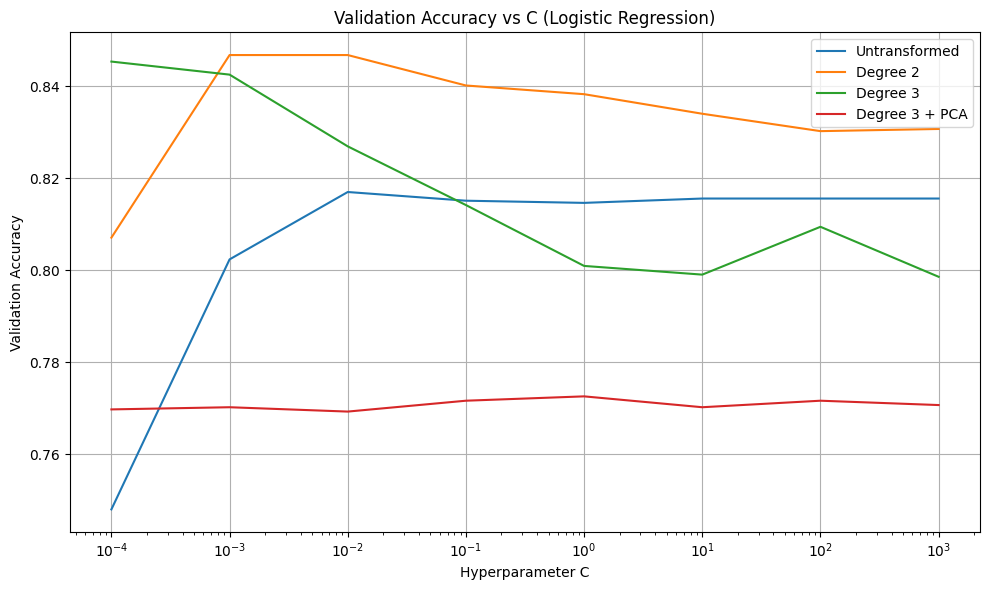

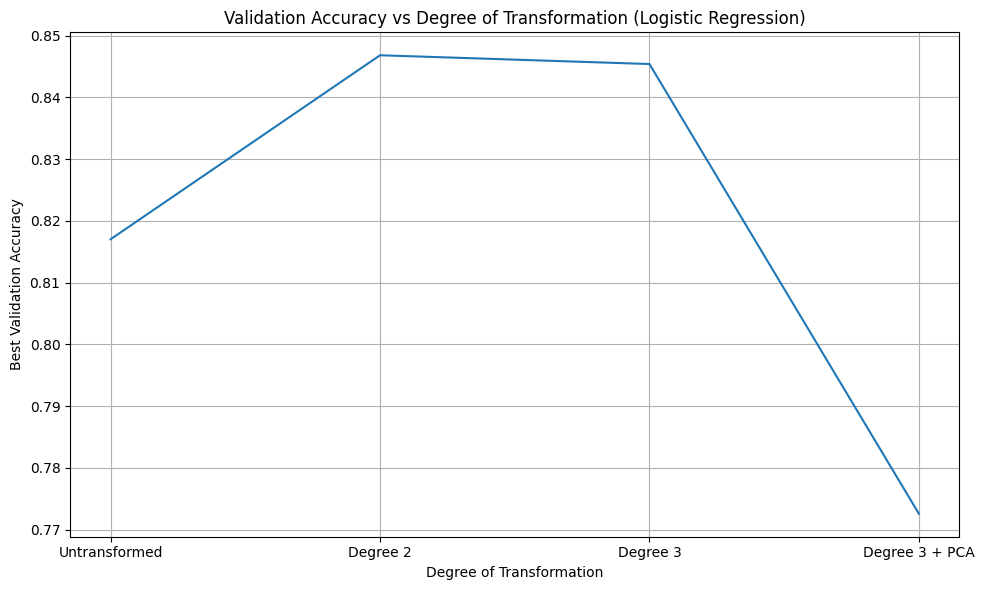

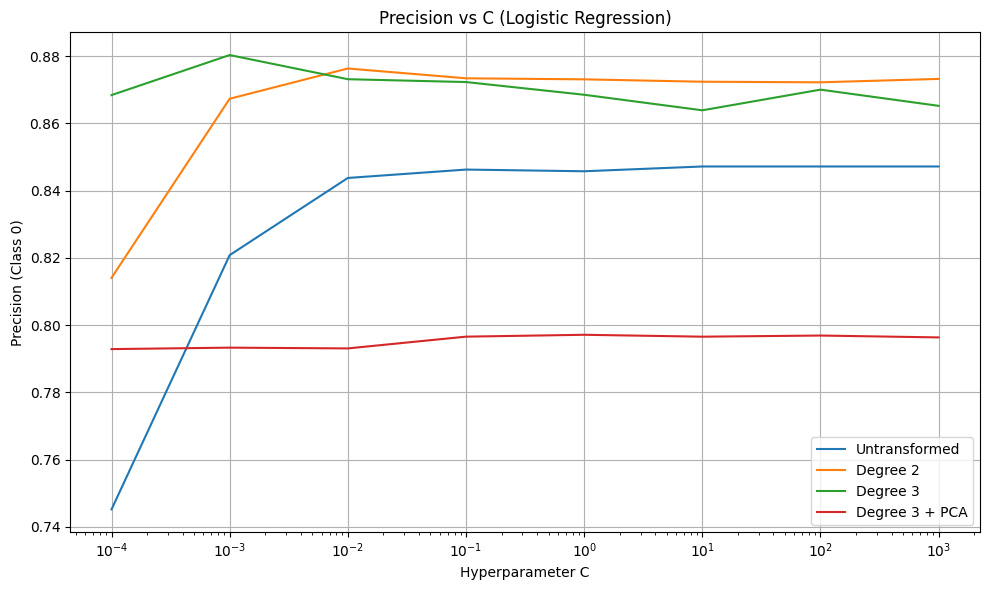

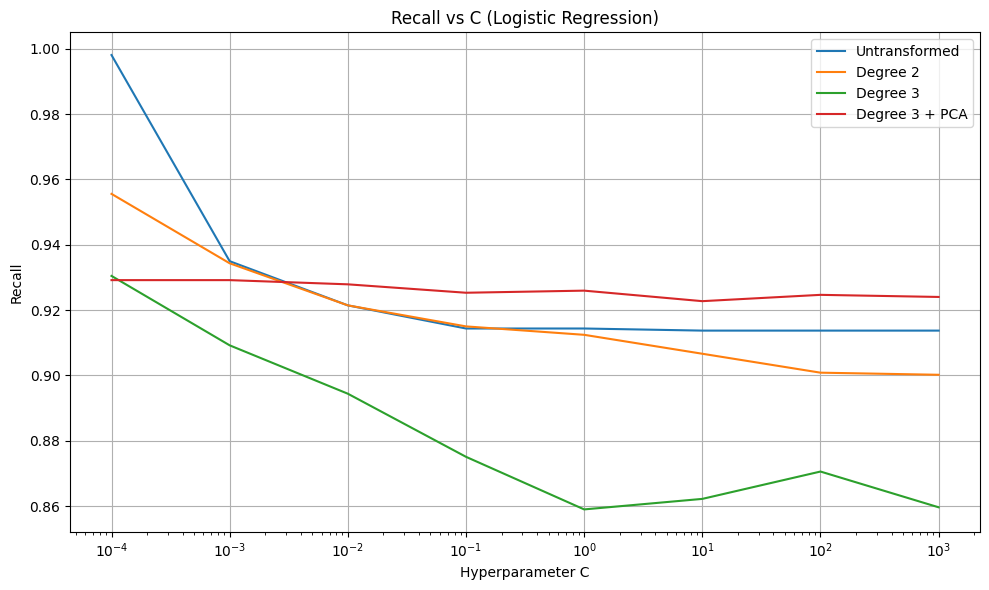

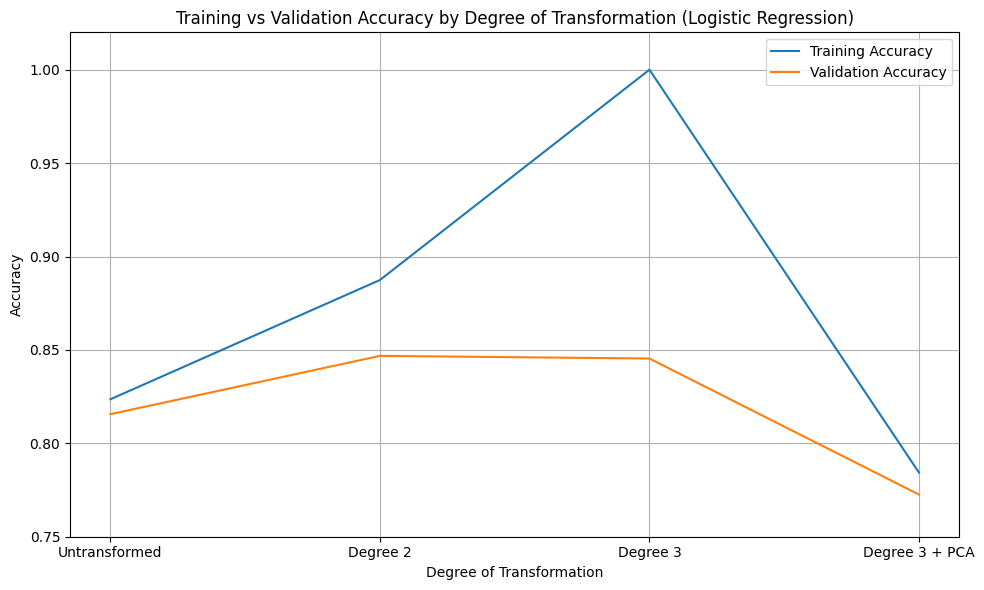

In [190]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

untransformed = [0.747991, 0.802364, 0.817021, 0.815130, 0.814657, 0.815603, 0.815603, 0.815603]
degree_2 = [0.807092, 0.846809, 0.846809, 0.840189, 0.838298, 0.834043, 0.830260, 0.830733]
degree_3 = [0.845390, 0.842553, 0.826950, 0.814184, 0.800946, 0.799054, 0.809456, 0.798582]
degree_3_pca = [0.769740, 0.770213, 0.769267, 0.771631, 0.772577, 0.770213, 0.771631, 0.770686]

plt.figure(figsize=(10,6))
plt.plot(c_values, untransformed, label = 'Untransformed')
plt.plot(c_values, degree_2, label = 'Degree 2')
plt.plot(c_values, degree_3, label = 'Degree 3')
plt.plot(c_values, degree_3_pca, label = 'Degree 3 + PCA')
plt.xscale('log') 
plt.xlabel('Hyperparameter C')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs C (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

transformations = ['Untransformed', 'Degree 2', 'Degree 3', 'Degree 3 + PCA']
best_accuracies = [max(untransformed), max(degree_2), max(degree_3), max(degree_3_pca)]

plt.figure(figsize=(10,6))
plt.plot(transformations, best_accuracies)
plt.ylabel('Best Validation Accuracy')
plt.xlabel('Degree of Transformation')
plt.title('Validation Accuracy vs Degree of Transformation (Logistic Regression)')
plt.grid(True)
plt.tight_layout()
plt.show()


precision_untransformed = [0.745192, 0.820803, 0.843750, 0.846246, 0.845742, 0.847164, 0.847164, 0.847164]
precision_deg2 = [0.814043, 0.867304, 0.876301, 0.873387, 0.873075, 0.872367, 0.872195, 0.873204]
precision_deg3 = [0.868389, 0.880299, 0.873116, 0.872272, 0.868490, 0.863871, 0.870013, 0.865198]
precision_deg3_pca = [0.792857, 0.793293, 0.793065, 0.796563, 0.797118, 0.796554, 0.796892, 0.796337]

plt.figure(figsize=(10, 6))
plt.plot(c_values, precision_untransformed, label='Untransformed')
plt.plot(c_values, precision_deg2, label='Degree 2')
plt.plot(c_values, precision_deg3, label='Degree 3')
plt.plot(c_values, precision_deg3_pca, label='Degree 3 + PCA')
plt.xscale('log')
plt.xlabel('Hyperparameter C')
plt.ylabel('Precision (Class 0)')
plt.title('Precision vs C (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


recall_untransformed = [0.998068, 0.934965, 0.921442, 0.914359, 0.914359, 0.913715, 0.913715, 0.913715]
recall_degree2 = [0.955570, 0.934321, 0.921442, 0.915003, 0.912428, 0.906632, 0.900837, 0.900193]
recall_degree3 = [0.930457, 0.909208, 0.894398, 0.875080, 0.858983, 0.862202, 0.870573, 0.859627]
recall_degree3_pca = [0.929169, 0.929169, 0.927882, 0.925306, 0.925950, 0.922730, 0.924662, 0.924018]

plt.figure(figsize=(10, 6))
plt.plot(c_values, recall_untransformed, label = 'Untransformed')
plt.plot(c_values, recall_degree2, label = 'Degree 2')
plt.plot(c_values, recall_degree3,label = 'Degree 3')
plt.plot(c_values, recall_degree3_pca, label = 'Degree 3 + PCA')
plt.xscale('log')
plt.xlabel('Hyperparameter C')
plt.ylabel('Recall')
plt.title('Recall vs C (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Best Accuracies
best_train_acc = [0.823589, 0.887425, 1.000000, 0.784375]
best_val_acc = [0.815603, 0.846809, 0.845390, 0.772577]

plt.figure(figsize=(10, 6))
plt.plot(transformations, best_train_acc, label='Training Accuracy')
plt.plot(transformations, best_val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy by Degree of Transformation (Logistic Regression)')
plt.xlabel('Degree of Transformation')
plt.ylabel('Accuracy')
plt.ylim(0.75, 1.02)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



### SVM

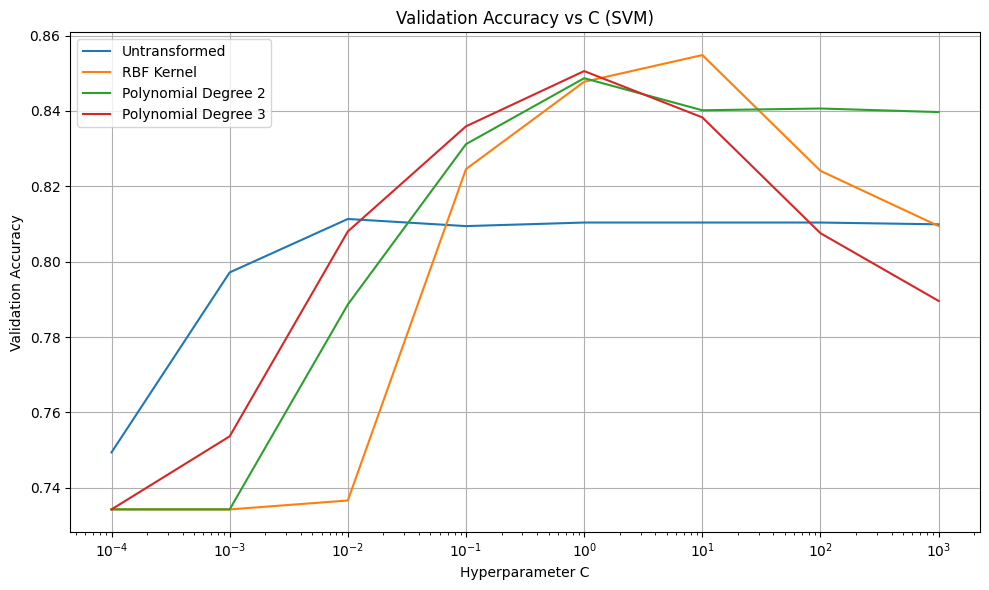

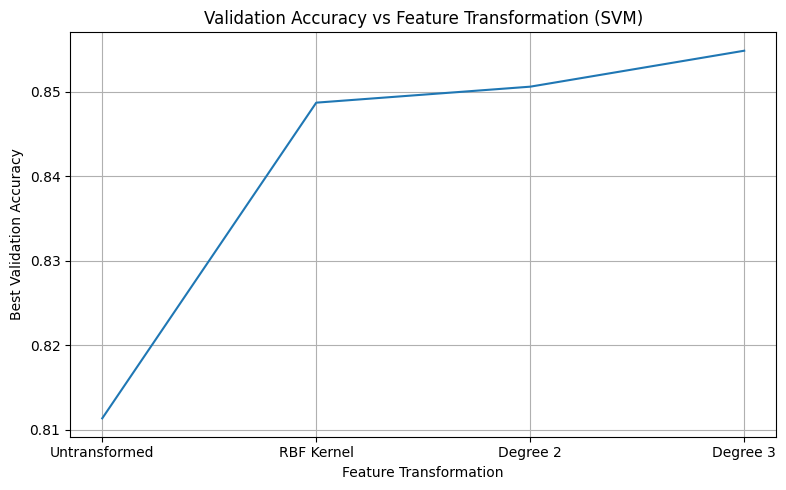

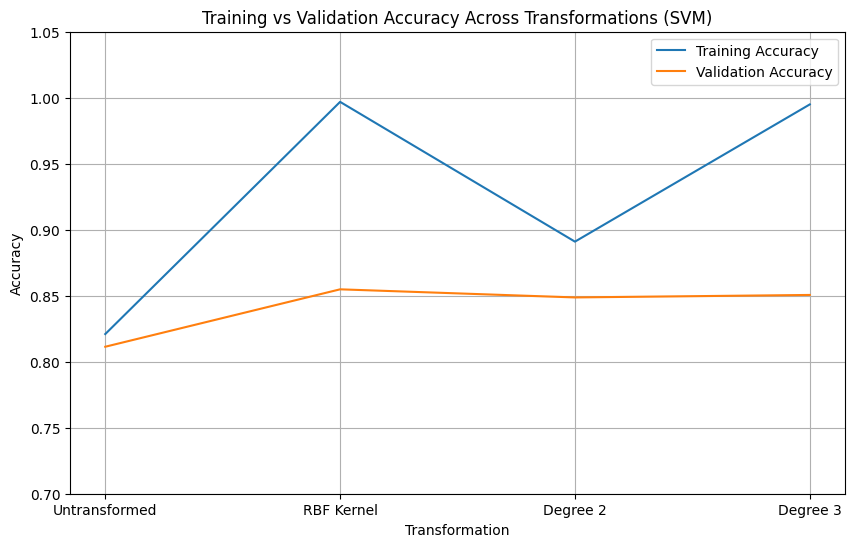

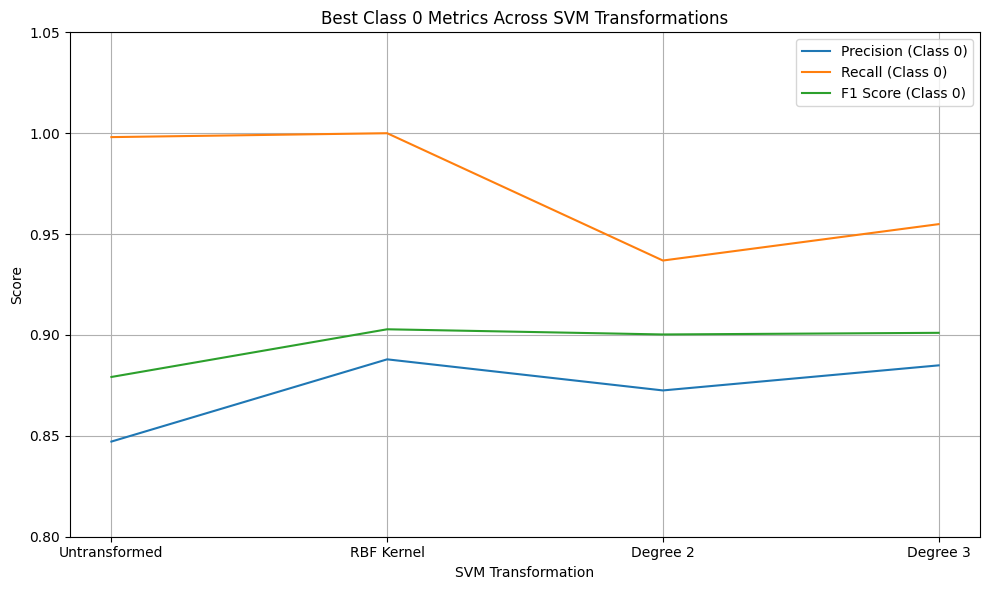

In [194]:
c_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

untransformed = [0.749409, 0.797163, 0.811348, 0.809456, 0.810402, 0.810402, 0.810402, 0.809929]
rbf = [0.734279, 0.734279, 0.736643, 0.824586, 0.847754, 0.854846, 0.824113, 0.809456]
degree_2 = [0.734279, 0.734279, 0.788652, 0.831206, 0.848700, 0.840189, 0.840662, 0.839716]
degree_3 = [0.734279, 0.753664, 0.808038, 0.835934, 0.850591, 0.838298, 0.807565, 0.789598]

plt.figure(figsize=(10, 6))
plt.plot(c_values, untransformed, label='Untransformed')
plt.plot(c_values, rbf, label='RBF Kernel')
plt.plot(c_values, degree_2, label='Polynomial Degree 2')
plt.plot(c_values, degree_3, label='Polynomial Degree 3')
plt.xscale('log')
plt.xlabel('Hyperparameter C')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs C (SVM)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_accuracies = [max(untransformed), max(degree_2), max(degree_3), max(rbf)]
transformations = ['Untransformed', 'RBF Kernel', 'Degree 2', 'Degree 3']

plt.figure(figsize=(8, 5))
plt.plot(transformations, best_accuracies)
plt.ylabel('Best Validation Accuracy')
plt.xlabel('Feature Transformation')
plt.title('Validation Accuracy vs Feature Transformation (SVM)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Best Accuracies
svm_train_accuracy = [0.820955, 0.996859, 0.890972, 0.994934]  
svm_val_accuracy = [0.811348, 0.854846, 0.848700, 0.850591]

plt.figure(figsize=(10, 6))
plt.plot(transformations, svm_train_accuracy, label='Training Accuracy')
plt.plot(transformations, svm_val_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy Across Transformations (SVM)')
plt.xlabel('Transformation')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# For highest accuracy row, we chose precision, recall, and F1 for class 0
precision_0 = [0.847164, 0.887920, 0.872508, 0.884933]
recall_0 = [0.998068, 1.000000, 0.936896, 0.954926]
f1_0 = [0.879182, 0.902817, 0.900249, 0.901064]

plt.figure(figsize=(10, 6))
plt.plot(transformations, precision_0, label='Precision (Class 0)')
plt.plot(transformations, recall_0, label='Recall (Class 0)')
plt.plot(transformations, f1_0, label='F1 Score (Class 0)')

plt.title('Best Class 0 Metrics Across SVM Transformations')
plt.xlabel('SVM Transformation')
plt.ylabel('Score')
plt.ylim(0.8, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Neural Networks

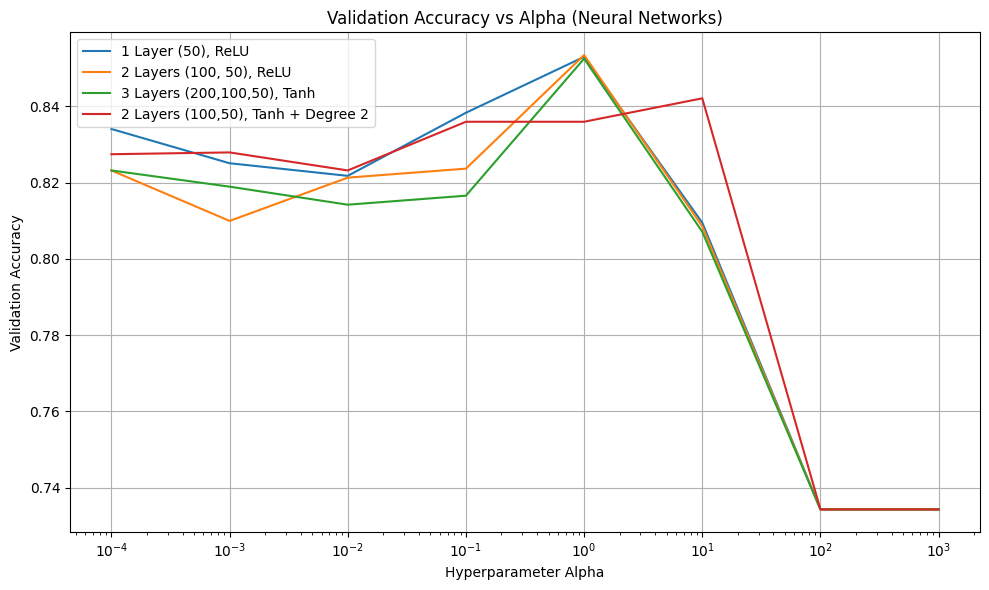

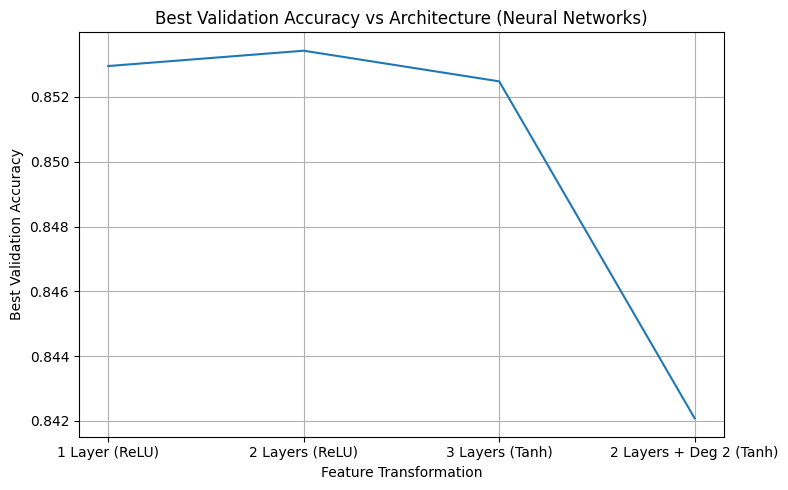

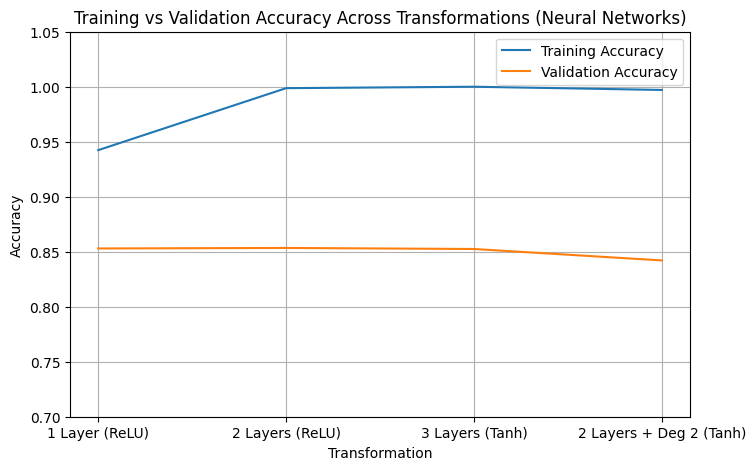

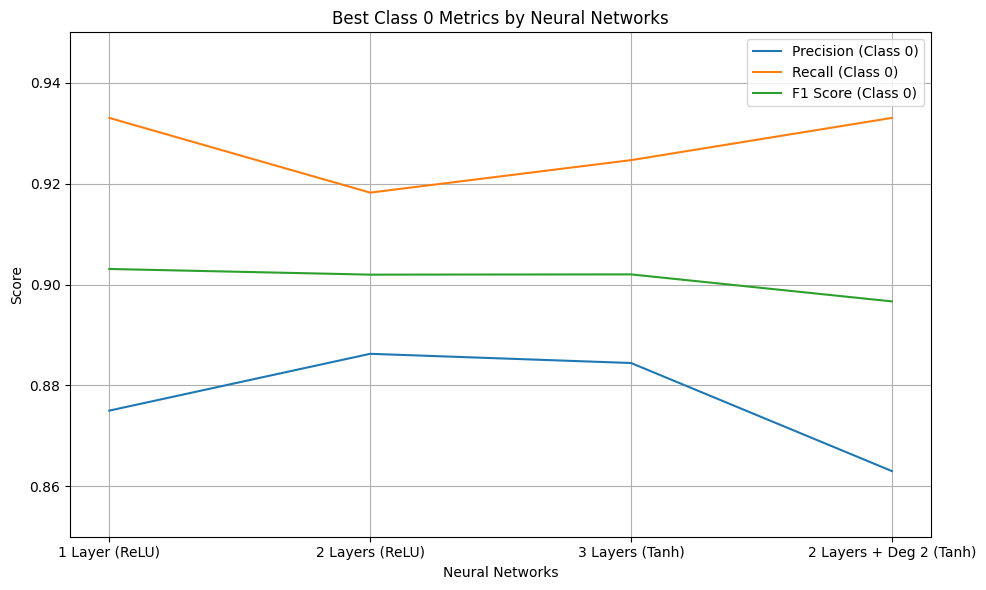

In [197]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

layer_1 = [0.834043, 0.825059, 0.821749, 0.838298, 0.852955, 0.809456, 0.734279, 0.734279]
layer_2 = [0.823168, 0.809929, 0.821277, 0.823641, 0.853428, 0.808511, 0.734279, 0.734279]
layer_3 = [0.823168, 0.818913, 0.814184, 0.816548, 0.852482, 0.807092, 0.734279, 0.734279]
layer_2_deg2 = [0.827423, 0.827896, 0.823168, 0.835934, 0.835934, 0.842080, 0.734279, 0.734279]

plt.figure(figsize=(10, 6))
plt.plot(alphas, layer_1, label = '1 Layer (50), ReLU')
plt.plot(alphas, layer_2, label = '2 Layers (100, 50), ReLU')
plt.plot(alphas, layer_3,label = '3 Layers (200,100,50), Tanh')
plt.plot(alphas, layer_2_deg2, label = '2 Layers (100,50), Tanh + Degree 2')

plt.xscale('log')
plt.xlabel('Hyperparameter Alpha')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Alpha (Neural Networks)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_accuracies = [max(layer_1), max(layer_2), max(layer_3), max(layer_2_deg2)]
transformations = ['1 Layer (ReLU)', '2 Layers (ReLU)', '3 Layers (Tanh)', '2 Layers + Deg 2 (Tanh)']

plt.figure(figsize=(8, 5))
plt.plot(transformations, best_accuracies)
plt.ylabel('Best Validation Accuracy')
plt.xlabel('Feature Transformation')
plt.title('Best Validation Accuracy vs Architecture (Neural Networks)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Best Accuracies
train_accuracy = [0.942345, 0.998683, 1, 0.997062]  
val_accuracy = [0.852955, 0.853428, 0.852482, 0.842080]

plt.figure(figsize=(8, 5))
plt.plot(transformations, train_accuracy, label='Training Accuracy')
plt.plot(transformations, val_accuracy, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy Across Transformations (Neural Networks)')
plt.xlabel('Transformation')
plt.ylabel('Accuracy')
plt.ylim(0.7, 1.05)
plt.legend()
plt.grid(True)
plt.show()

# For highest accuracy row, we chose precision, recall, and F1 for class 0
precision_0 = [0.875000, 0.886265, 0.884441, 0.863014]
recall_0 = [ 0.933033, 0.918223, 0.924662, 0.933033]
f1_0 = [0.903085, 0.901961, 0.902010, 0.896658]

plt.figure(figsize=(10, 6))
plt.plot(transformations, precision_0, label='Precision (Class 0)')
plt.plot(transformations, recall_0, label='Recall (Class 0)')
plt.plot(transformations, f1_0, label='F1 Score (Class 0)')

plt.title('Best Class 0 Metrics by Neural Networks')
plt.ylabel('Score')
plt.xlabel('Neural Networks')
plt.ylim(0.85, 0.95)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
